# 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [2]:
df = pd.read_csv("Top Indian Places to Visit.csv")
df.head()


,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,NaN,Historical,Yes,2.60,Evening
1,1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,NaN,Historical,Yes,0.40,Afternoon
2,2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,NaN,Religious,No,0.40,Afternoon
3,3,Northern,Delhi,Delhi,Waste to Wonder Park,Theme Park,2019,2.0,4.1,50,Yes,Monday,Environmental,Yes,0.27,Evening
4,4,Northern,Delhi,Delhi,Jantar Mantar,Observatory,1724,2.0,4.2,15,Yes,NaN,Scientific,Yes,0.31,Morning


# 2.Data cleaning 

In [3]:
# Check missing values
df.isnull().sum()



Unnamed: 0                            0
Zone                                  0
State                                 0
City                                  0
Name                                  0
Type                                  0
Establishment Year                    0
time needed to visit in hrs           0
Google review rating                  0
Entrance Fee in INR                   0
Airport with 50km Radius              0
Weekly Off                          293
Significance                          0
DSLR Allowed                          0
Number of google review in lakhs      0
Best Time to visit                    0
dtype: int64

In [4]:
# Fill missing values
df.fillna("Unknown", inplace=True)
df

,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,Unknown,Historical,Yes,2.60,Evening
1,1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,Unknown,Historical,Yes,0.40,Afternoon
2,2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,Unknown,Religious,No,0.40,Afternoon
3,3,Northern,Delhi,Delhi,Waste to Wonder Park,Theme Park,2019,2.0,4.1,50,Yes,Monday,Environmental,Yes,0.27,Evening
4,4,Northern,Delhi,Delhi,Jantar Mantar,Observatory,1724,2.0,4.2,15,Yes,Unknown,Scientific,Yes,0.31,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,320,Western,Gujarat,Gandhinagar,Akshardham,Temple,1992,3.0,4.6,0,Yes,Monday,Religious,No,0.18,All
321,321,Central,Uttar Pradesh,Agra,Agra Fort,Fort,1565,2.0,4.5,40,Yes,Unknown,Historical,Yes,1.30,Afternoon
322,322,Central,Madhya Pradesh,Bhopal,Madhya Pradesh Tribal Museum,Museum,2013,2.0,4.7,10,Yes,Monday,Cultural,Yes,0.15,All
323,323,Northern,Rajasthan,Jaipur,City Palace,Palace,1727,2.0,4.4,200,Yes,Unknown,Historical,Yes,0.51,Morning


In [5]:

# Remove duplicate rows
df.drop_duplicates(inplace=True)
df

,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,Unknown,Historical,Yes,2.60,Evening
1,1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,Unknown,Historical,Yes,0.40,Afternoon
2,2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,Unknown,Religious,No,0.40,Afternoon
3,3,Northern,Delhi,Delhi,Waste to Wonder Park,Theme Park,2019,2.0,4.1,50,Yes,Monday,Environmental,Yes,0.27,Evening
4,4,Northern,Delhi,Delhi,Jantar Mantar,Observatory,1724,2.0,4.2,15,Yes,Unknown,Scientific,Yes,0.31,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,320,Western,Gujarat,Gandhinagar,Akshardham,Temple,1992,3.0,4.6,0,Yes,Monday,Religious,No,0.18,All
321,321,Central,Uttar Pradesh,Agra,Agra Fort,Fort,1565,2.0,4.5,40,Yes,Unknown,Historical,Yes,1.30,Afternoon
322,322,Central,Madhya Pradesh,Bhopal,Madhya Pradesh Tribal Museum,Museum,2013,2.0,4.7,10,Yes,Monday,Cultural,Yes,0.15,All
323,323,Northern,Rajasthan,Jaipur,City Palace,Palace,1727,2.0,4.4,200,Yes,Unknown,Historical,Yes,0.51,Morning


# 3. Exploratory Data analysis

In [6]:
# Statistical summary
df.describe(include='all')


,Unnamed: 0,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Weekly Off,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
count,325.000000,325,325,325,325,325,325,325.000000,325.000000,325.000000,325,325,325,325,325.000000,325
unique,NaN,6,33,214,321,78,162,NaN,NaN,NaN,2,6,25,2,NaN,7
top,NaN,Southern,Uttar Pradesh,Delhi,City Palace,Temple,Unknown,NaN,NaN,NaN,Yes,Unknown,Historical,Yes,NaN,All
freq,NaN,98,23,16,2,59,111,NaN,NaN,NaN,227,293,78,265,NaN,164
mean,162.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.807692,4.486154,115.809231,NaN,NaN,NaN,NaN,0.408438,NaN
std,93.963645,NaN,NaN,NaN,NaN,NaN,NaN,0.971398,0.274580,530.859785,NaN,NaN,NaN,NaN,0.646668,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,1.400000,0.000000,NaN,NaN,NaN,NaN,0.010000,NaN
25%,81.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,4.400000,0.000000,NaN,NaN,NaN,NaN,0.059000,NaN
50%,162.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,4.500000,0.000000,NaN,NaN,NaN,NaN,0.170000,NaN
75%,243.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,4.600000,40.000000,NaN,NaN,NaN,NaN,0.500000,NaN


## Top states visualization

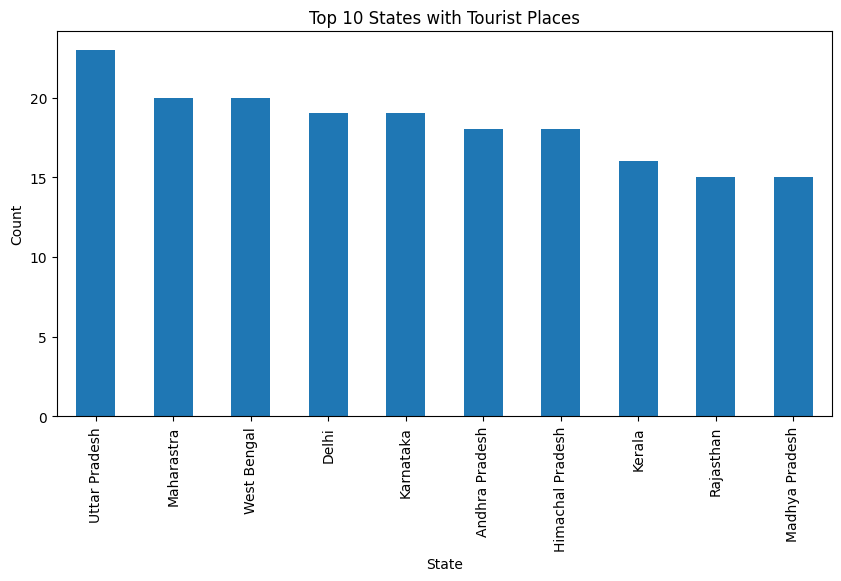

In [7]:
plt.figure(figsize=(10,5))
df['State'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 States with Tourist Places")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

In [8]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Unnamed: 0', 'Zone', 'State', 'City', 'Name', 'Type',
       'Establishment Year', 'time needed to visit in hrs',
       'Google review rating', 'Entrance Fee in INR',
       'Airport with 50km Radius', 'Weekly Off', 'Significance',
       'DSLR Allowed', 'Number of google review in lakhs',
       'Best Time to visit'],
      dtype='object')


In [9]:
['Place', 'State', 'Type']


['Place', 'State', 'Type']

## Category Distribution

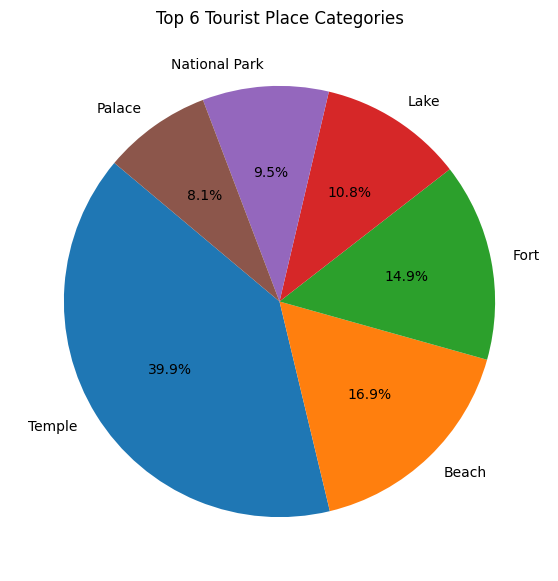

In [10]:
top_categories = df['Type'].value_counts().head(6)

plt.figure(figsize=(7,7))
top_categories.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top 6 Tourist Place Categories")
plt.ylabel("")
plt.show()


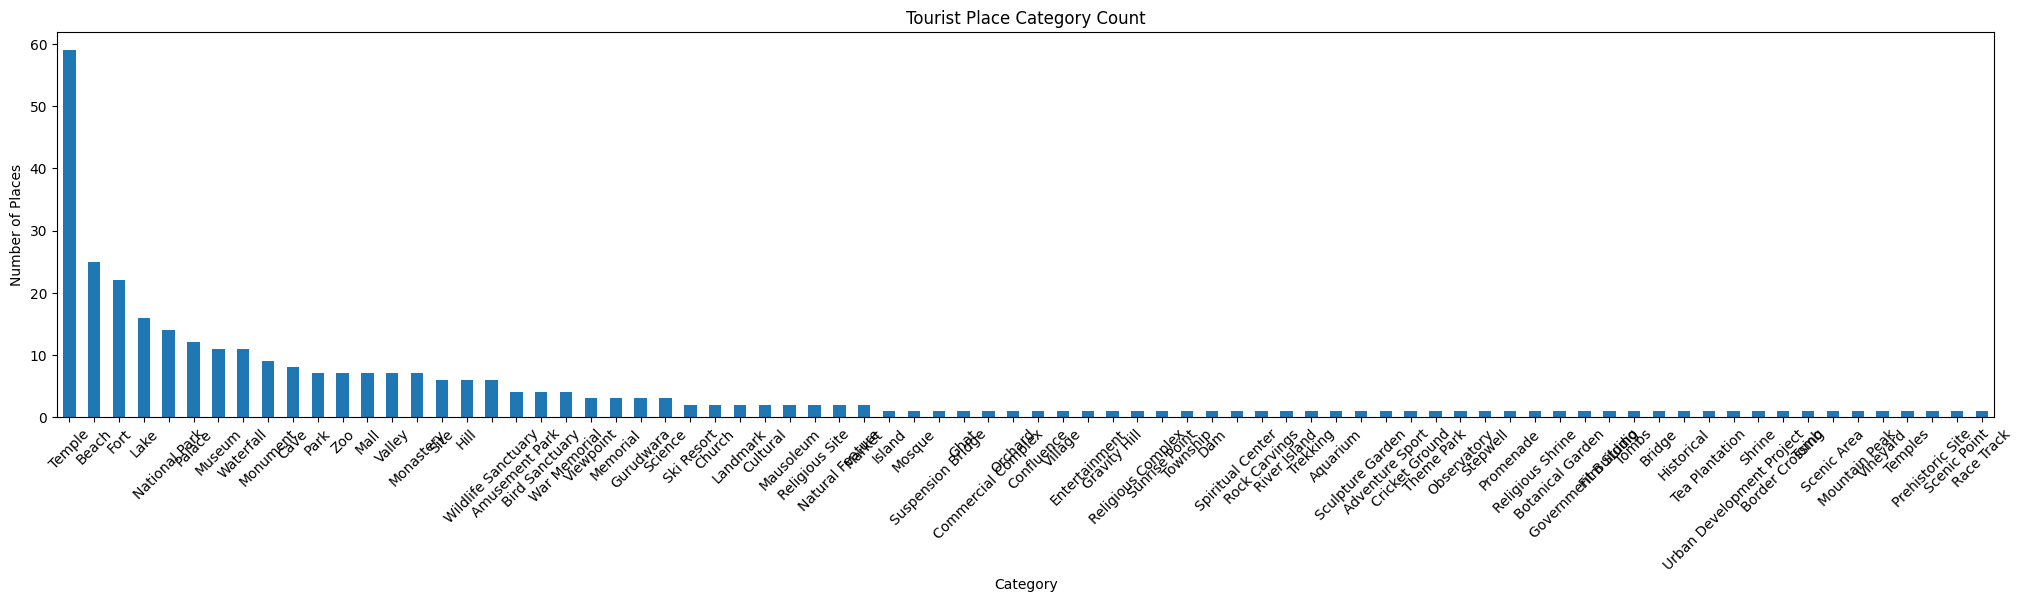

In [11]:
plt.figure(figsize=(25,5))
df['Type'].value_counts().plot(kind='bar')
plt.title("Tourist Place Category Count")
plt.xlabel("Category")
plt.ylabel("Number of Places")
plt.xticks(rotation=45)
plt.show()


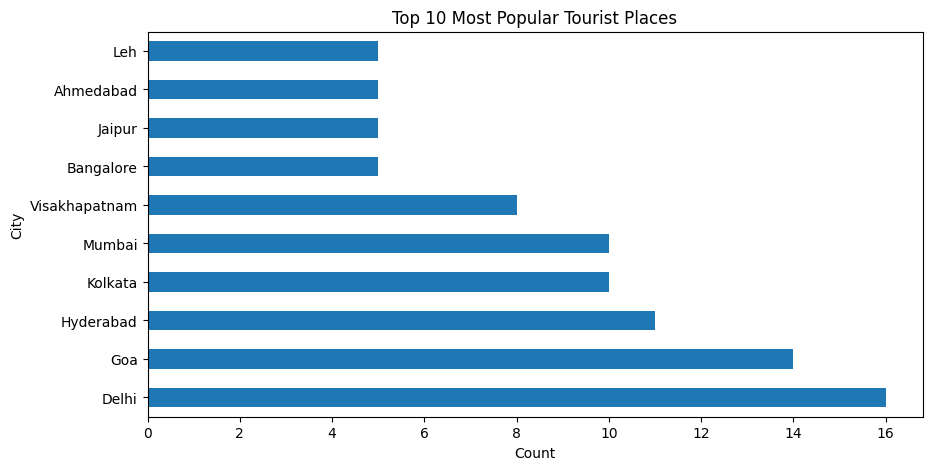

In [12]:
plt.figure(figsize=(10,5))
df['City'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Most Popular Tourist Places")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()


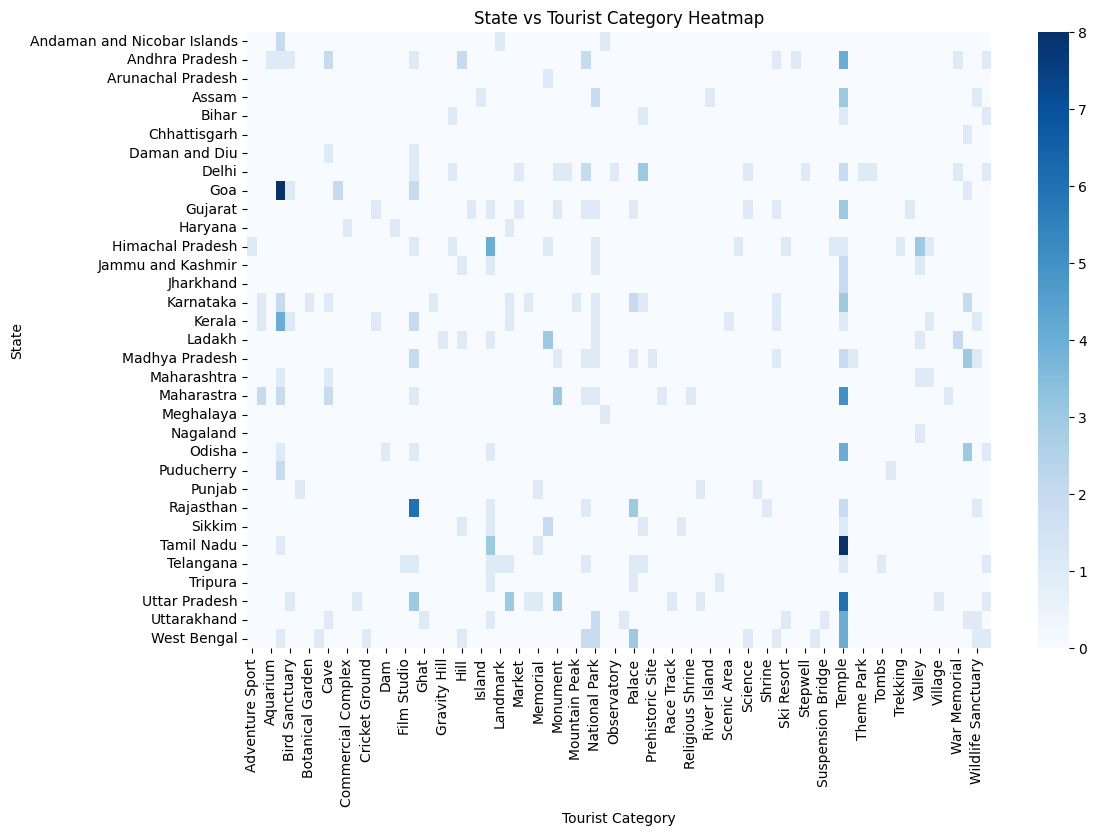

In [13]:
state_category = pd.crosstab(df['State'], df['Type'])

plt.figure(figsize=(12,8))
sns.heatmap(state_category, cmap='Blues')
plt.title("State vs Tourist Category Heatmap")
plt.xlabel("Tourist Category")
plt.ylabel("State")
plt.show()


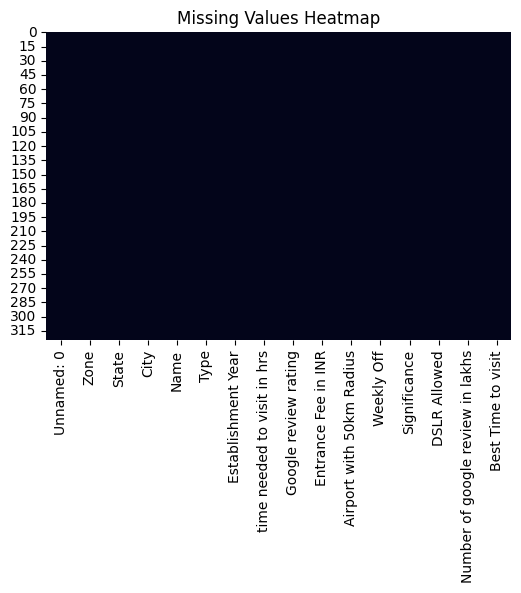

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


## 4. Features of engineering

### Encoding Categorical Features

In [15]:
le_state = LabelEncoder()
le_Type = LabelEncoder()

df['State_enc'] = le_state.fit_transform(df['State'])
df['Type_enc'] = le_Type.fit_transform(df['Type'])


### Feature Selection

In [16]:
X = df[['State_enc']]
y = df['Type_enc']
X
y

0      74
1      65
2      62
3      64
4      38
       ..
320    62
321    17
322    35
323    40
324    35
Name: Type_enc, Length: 325, dtype: int32

# 5. Model Training

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Feature Scaling (for LR & KNN)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled
X_test_scaled

array([[ 0.46043874],
       [-0.25825638],
       [-1.69564662],
       [-1.07962223],
       [ 0.6657802 ],
       [ 1.48714606],
       [ 0.56310947],
       [-0.56626857],
       [-0.15558565],
       [-0.25825638],
       [ 1.28180459],
       [-1.69564662],
       [-0.25825638],
       [-0.05291492],
       [-0.87428077],
       [-0.6689393 ],
       [-0.05291492],
       [-0.05291492],
       [ 0.15242655],
       [-1.07962223],
       [ 0.76845094],
       [ 1.38447532],
       [ 1.48714606],
       [-1.49030516],
       [ 0.6657802 ],
       [-0.36092711],
       [-0.36092711],
       [-0.36092711],
       [-0.9769515 ],
       [ 0.87112167],
       [ 0.9737924 ],
       [-0.15558565],
       [-0.77161004],
       [ 1.38447532],
       [-1.38763442],
       [ 1.38447532],
       [-0.9769515 ],
       [ 1.07646313],
       [-0.6689393 ],
       [-0.6689393 ],
       [ 0.9737924 ],
       [ 1.48714606],
       [-0.36092711],
       [ 1.38447532],
       [ 1.48714606],
       [-0

## Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_pred

array([62, 62,  3, 62, 62, 62, 62, 62, 62, 62, 62,  3, 62, 62, 62, 62, 62,
       62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62,
       62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62,
       62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62])

## KNN

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_pred

array([62,  3, 62, 21, 17, 40, 62, 22, 31,  3, 62, 62,  3, 62, 13, 17, 62,
       62,  1, 21, 17, 18, 40, 36, 17,  8,  8,  8,  3, 31, 62, 31, 62, 18,
       36, 18,  3, 16, 17, 17, 62, 40,  8, 18, 40, 62, 17, 62,  3,  1, 13,
       17, 21, 13, 13, 62,  8, 18, 21, 13, 62, 62,  3,  1, 40])

## Decision Tree

In [21]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_pred

array([62,  3, 62, 35, 47, 36, 67, 22, 31,  3, 62, 62,  3, 75, 62, 25, 75,
       75, 62, 35, 17, 62, 36, 62, 47, 40, 40, 40,  3, 31, 62, 31, 15, 62,
       21, 62,  3, 16, 25, 25, 62, 36, 40, 62, 36, 15, 17, 62,  3, 62, 62,
       17, 35, 62, 62, 67, 21, 62, 35, 62, 75, 62,  3, 62, 36])

## Random Forest

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred


array([75,  3, 62, 62, 53, 36, 67, 25, 31,  3, 62, 62,  3, 75, 62, 25, 75,
       75, 62, 62, 17, 62, 36, 62, 53, 40, 40, 40,  3, 31, 62, 31, 15, 62,
       21, 62,  3, 40, 25, 25, 62, 36, 40, 62, 36, 15, 17, 75,  3, 62, 62,
       17, 62, 62, 62, 67, 21, 62, 62, 62, 75, 75,  3, 62, 36])

## Gradient boosting

In [23]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_pred

array([75,  3, 62, 41, 53, 36, 67, 62, 31,  3, 62, 62,  3, 75, 62, 70, 75,
       75, 62, 41, 17, 62, 36, 62, 53, 62, 62, 62,  3, 31, 62, 31, 15, 62,
       21, 62,  3, 25, 70, 70, 62, 36, 62, 62, 36, 15, 17, 75,  3, 62, 62,
       17, 41, 62, 62, 67, 21, 62, 41, 62, 75, 75,  3, 62, 36])

# 6. Model Evaluation

In [24]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred)
}

results


{'Logistic Regression': 0.13846153846153847,
 'KNN': 0.09230769230769231,
 'Decision Tree': 0.12307692307692308,
 'Random Forest': 0.1076923076923077,
 'Gradient Boosting': 0.13846153846153847}

In [25]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           3       0.29      0.29      0.29         7
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         0
          17       0.33      0.20      0.25         5
          20       0.00      0.00      0.00         1
          21       0.00      0.00      0.00         1
          25       0.25      0.25      0.25         4
          27       0.00      0.00      0.00         2
          28       0.00      0.00      0.00         2
          29       0.00      0.00      0.00         1
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         0
          32       0.00      0.00      0.00         2
          35       0.00    

C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sneha\anaconda3\Lib\site-pa

### Define target


In [32]:
y = df['Type']     # NOT place name
X = df.drop(['Type', 'State'], axis=1)


### encode target


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


### Train + Predict

In [35]:
best_rf_pred = best_rf.predict(X_test)


### Confusion Matrix

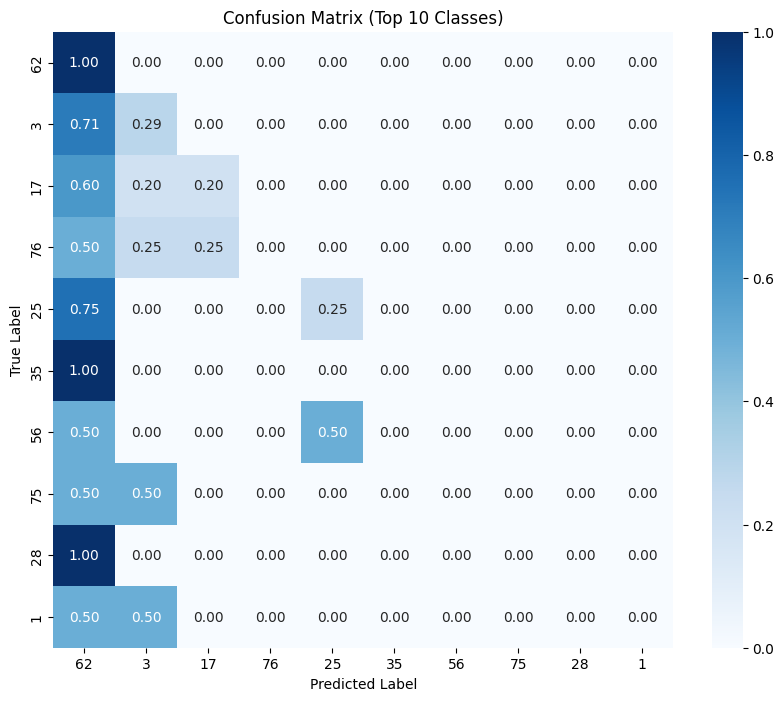

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 most frequent labels
top_labels = y_test.value_counts().index[:10]

mask = y_test.isin(top_labels)
y_test_top = y_test[mask]
y_pred_top = best_rf_pred[mask]

cm = confusion_matrix(y_test_top, y_pred_top, labels=top_labels, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels
)

plt.title("Confusion Matrix (Top 10 Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# 7. Hyperparameter Tuning (random Forest)

In [43]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)


C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [73]:
best_model = grid.best_estimator_
best_model


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [74]:
best_pred = best_model.predict(X_test)
accuracy_score(y_test, best_pred)


0.15384615384615385

# Final Result

In [44]:
final_results = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

final_results


,Model,Accuracy
0,Logistic Regression,0.138462
4,Gradient Boosting,0.138462
2,Decision Tree,0.123077
3,Random Forest,0.107692
1,KNN,0.092308
